In [1]:
from sklearn.datasets import make_regression
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
X,Y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':Y})
df.head()

,feature1,feature2,target
0,-0.018430,-0.908298,-107.485120
1,-0.086019,1.134444,102.615562
2,0.462271,-0.807684,-19.182612
3,0.034366,-0.655507,-59.870417
4,1.683720,-0.728082,80.986341


In [4]:
df.shape

(100, 3)

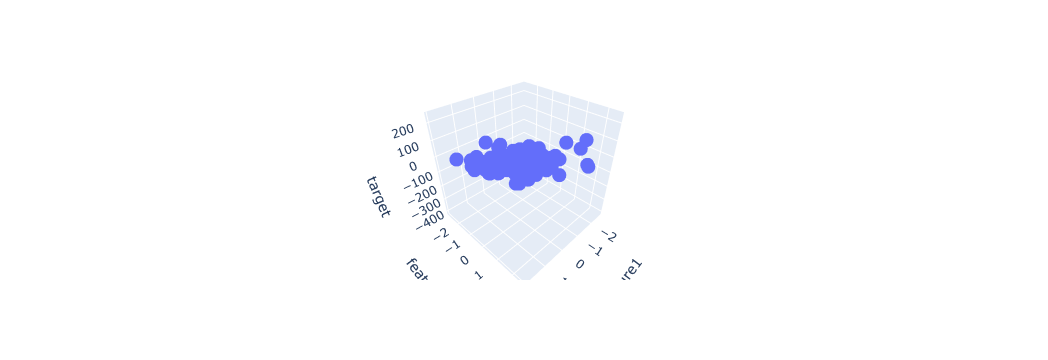

In [5]:
fig = px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

In [6]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,3)

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[85.09,79.4 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.564
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[9.66,8.1 ]"


In [9]:
Y_pred = lr.predict(X_test)

In [10]:
print(f"MAE: {mean_absolute_error(Y_test,Y_pred)}")
print(f"MSE: {mean_squared_error(Y_test,Y_pred)}")
print(f"R2 Score: {r2_score(Y_test,Y_pred)}")

MAE: 27.93275739909192
MSE: 1117.1865769157325
R2 Score: 0.9264908755497736


In [11]:
X = np.linspace(-5,5,10)
Y  = np.linspace(-5,5,10)
xGrid , yGrid  = np.meshgrid(X,Y)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)
Z = z_final

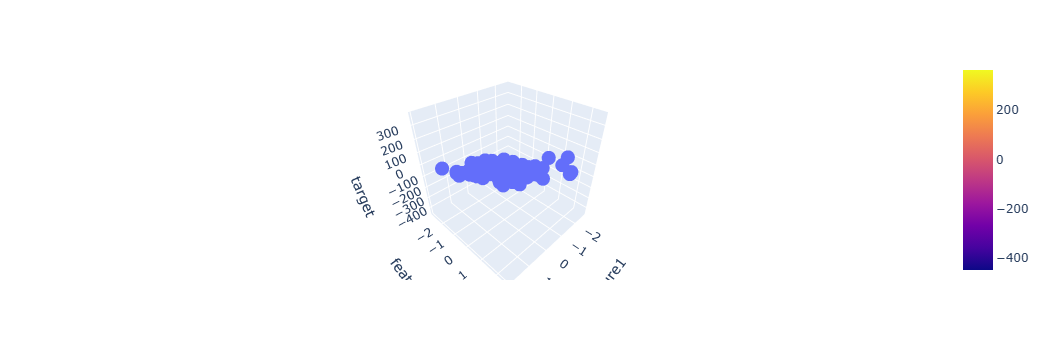

In [16]:
fig = px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.add_trace(go.Surface(x=xGrid,y=yGrid,z=Z))
fig.show()

In [17]:
lr.coef_

array([85.09292434, 79.39625578])

In [18]:
lr.intercept_

np.float64(-1.5644910198077868)